<a href="https://colab.research.google.com/github/Fayshal007/skill-morph-codes/blob/main/Obesity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Machine Learning: Obesity Prediction

# 1. Import Libraries

In [286]:
# 1. Import Libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
import warnings; warnings.filterwarnings('ignore')
print("✅ All libraries loaded!")

✅ All libraries loaded!


# 2. Load the Dataset

In [287]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [288]:
data = pd.read_csv('/content/drive/MyDrive/datasets_skill_morph/class 8/ObesityDataSet_raw_and_data_sinthetic.csv')


In [289]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [290]:
data = data.rename(columns={
    'FAVC': 'high_cal_food',
    'FCVC': 'veg_freq',
    'NCP': 'meal_count',
    'CAEC': 'snack_freq',
    'SMOKE': 'smoker',
    'CH2O': 'water_intake',
    'SCC': 'calorie_tracking',
    'FAF': 'activity_freq',
    'TUE': 'screen_time',
    'CALC': 'alcohol_freq',
    'MTRANS': 'transport_mode'
})

In [291]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,high_cal_food,veg_freq,meal_count,snack_freq,smoker,water_intake,calorie_tracking,activity_freq,screen_time,alcohol_freq,transport_mode,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# 3. Explore the Data (EDA)

In [292]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   high_cal_food                   2111 non-null   object 
 6   veg_freq                        2111 non-null   float64
 7   meal_count                      2111 non-null   float64
 8   snack_freq                      2111 non-null   object 
 9   smoker                          2111 non-null   object 
 10  water_intake                    2111 non-null   float64
 11  calorie_tracking                2111 non-null   object 
 12  activity_freq                   21

In [293]:
print(f"Missing: {data.isnull().sum().sum()}")
print(f"\n Target Distribution:\n{data['NObeyesdad'].value_counts()}")

Missing: 0

 Target Distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


# 4.Data preprocessing

In [294]:
data_cat= data.select_dtypes(include="object")
data_cat.head()

,Gender,family_history_with_overweight,high_cal_food,snack_freq,smoker,calorie_tracking,alcohol_freq,transport_mode,NObeyesdad
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,Normal_Weight
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,Normal_Weight
3,Male,no,no,Sometimes,no,no,Frequently,Walking,Overweight_Level_I
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_II


### Add BMI feature

In [295]:
data['BMI'] = data['Weight'] / (data['Height'] ** 2)

In [296]:
for i in data_cat.columns.to_list():
  print(data_cat[i].value_counts())
  print("")

Gender
Male      1068
Female    1043
Name: count, dtype: int64

family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

high_cal_food
yes    1866
no      245
Name: count, dtype: int64

snack_freq
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

smoker
no     2067
yes      44
Name: count, dtype: int64

calorie_tracking
no     2015
yes      96
Name: count, dtype: int64

alcohol_freq
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

transport_mode
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64



## using ordinalEncoder for order cloumns

In [297]:
from sklearn.preprocessing import OrdinalEncoder
# define order
categories = [
    ['no', 'Sometimes', 'Frequently', 'Always'], # snack_freq
    ['no', 'Sometimes', 'Frequently', 'Always'], # alcohol_freq
    ['Bike', 'Walking', 'Motorbike', 'Public_Transportation', 'Automobile'] ## transport_mode
]
ordinal_encoder = OrdinalEncoder(categories=categories)

### encode for both snakc_freq and alcohol_freq columns

In [298]:
data[['snack_freq', 'alcohol_freq', 'transport_mode']] = (
    ordinal_encoder.fit_transform(data[['snack_freq', 'alcohol_freq', 'transport_mode']])
    .astype(int)
)

In [299]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,high_cal_food,veg_freq,meal_count,snack_freq,smoker,water_intake,calorie_tracking,activity_freq,screen_time,alcohol_freq,transport_mode,NObeyesdad,BMI
0,Female,21,1.62,64.0,yes,no,2.0,3.0,1,no,2.0,no,0.0,1.0,0,3,Normal_Weight,24.386526
1,Female,21,1.52,56.0,yes,no,3.0,3.0,1,yes,3.0,yes,3.0,0.0,1,3,Normal_Weight,24.238227
2,Male,23,1.80,77.0,yes,no,2.0,3.0,1,no,2.0,no,2.0,1.0,2,3,Normal_Weight,23.765432
3,Male,27,1.80,87.0,no,no,3.0,3.0,1,no,2.0,no,2.0,0.0,2,1,Overweight_Level_I,26.851852
4,Male,22,1.78,89.8,no,no,2.0,1.0,1,no,2.0,no,0.0,0.0,1,3,Overweight_Level_II,28.342381


## use OneHotEncoder when categories have NO order


In [300]:
from sklearn.preprocessing import OneHotEncoder

# columns for one-hot encoding
cols = [
    'Gender',
    'family_history_with_overweight',
    'high_cal_food',
    'smoker',
    'calorie_tracking'
]

# create encoder
encoder = OneHotEncoder(sparse_output=False)

# encode columns
encoded = encoder.fit_transform(data[cols])

# create dataframe of encoded columns
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cols),
    index=data.index
)

# remove original columns and add encoded columns
data = pd.concat([data.drop(columns=cols), encoded_df], axis=1)

### use label encoder

In [301]:
from sklearn.preprocessing import LabelEncoder

# create encoder
le = LabelEncoder()

# apply encoding
data['NObeyesdad'] = le.fit_transform(data['NObeyesdad'])

# see mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(mapping)
print(data[['NObeyesdad']].head())

{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}
   NObeyesdad
0           1
1           1
2           1
3           5
4           6


In [302]:
data.head()

,Age,Height,Weight,veg_freq,meal_count,snack_freq,water_intake,activity_freq,screen_time,alcohol_freq,...,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,high_cal_food_no,high_cal_food_yes,smoker_no,smoker_yes,calorie_tracking_no,calorie_tracking_yes
0,21,1.62,64.0,2.0,3.0,1,2.0,0.0,1.0,0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
1,21,1.52,56.0,3.0,3.0,1,3.0,3.0,0.0,1,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
2,23,1.80,77.0,2.0,3.0,1,2.0,2.0,1.0,2,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3,27,1.80,87.0,3.0,3.0,1,2.0,2.0,0.0,2,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,22,1.78,89.8,2.0,1.0,1,2.0,0.0,0.0,1,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [303]:
data.columns

Index(['Age', 'Height', 'Weight', 'veg_freq', 'meal_count', 'snack_freq',
       'water_intake', 'activity_freq', 'screen_time', 'alcohol_freq',
       'transport_mode', 'NObeyesdad', 'BMI', 'Gender_Female', 'Gender_Male',
       'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'high_cal_food_no',
       'high_cal_food_yes', 'smoker_no', 'smoker_yes', 'calorie_tracking_no',
       'calorie_tracking_yes'],
      dtype='object')

# 5. Prepare Features & Target

In [304]:
X = data.drop(columns=['NObeyesdad'])
y = data['NObeyesdad']

In [305]:
# 5. Train-Test Split <a id='5'></a>
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=20,
    stratify=y
)
print(f"📚 Training: {X_train.shape} | 🧪 Testing: {X_test.shape}")

📚 Training: (1688, 22) | 🧪 Testing: (423, 22)


In [306]:
# 6. Train the Decision Tree
model = DecisionTreeClassifier(max_depth=7, random_state=20)
model.fit(X_train, y_train)
print("✅ Model training complete!")

✅ Model training complete!


In [307]:
predictions = model.predict(X_test)
prediction_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, predictions)
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

🎯 Accuracy: 0.9764 (97.64%)


In [308]:
accuracy  = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='weighted')
recall    = recall_score(y_test, predictions, average='weighted')
f1        = f1_score(y_test, predictions, average='weighted')

print(f"Accuracy : {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

Accuracy : 0.9764 | Precision: 0.9763 | Recall: 0.9764 | F1: 0.9762


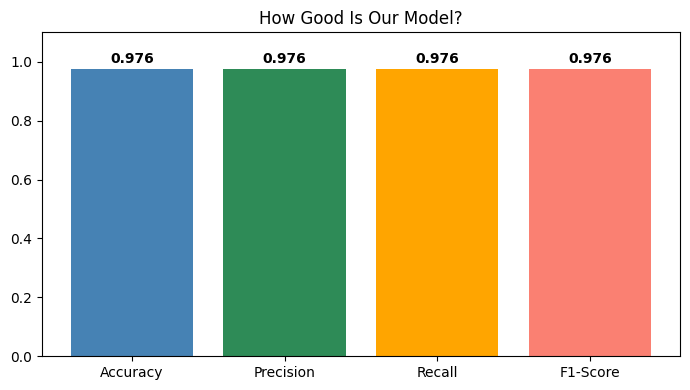

In [309]:
# Visual comparison
fig, ax = plt.subplots(figsize=(7, 4))
names, vals = ['Accuracy', 'Precision', 'Recall', 'F1-Score'], [accuracy, precision, recall, f1]
bars = ax.bar(names, vals, color=['steelblue', 'seagreen', 'orange', 'salmon'])
ax.set_ylim(0, 1.1); ax.set_title('How Good Is Our Model?')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion Matrix

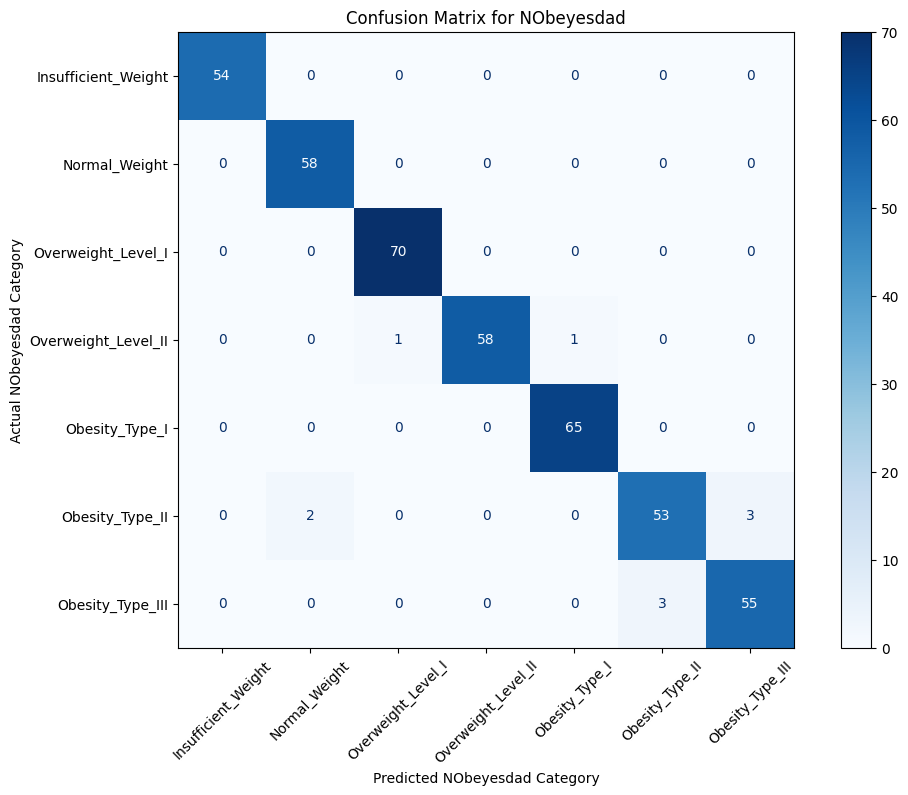

In [310]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Original category names of NObeyesdad
original_labels = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

# Encoded labels
encoded_labels = np.arange(len(original_labels))

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=encoded_labels
)

# Display with original category values
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=original_labels
)

fig, ax = plt.subplots(figsize=(12, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Confusion Matrix for NObeyesdad")
plt.xlabel("Predicted NObeyesdad Category")
plt.ylabel("Actual NObeyesdad Category")
plt.show()

# 10. ROC Curve & AUC

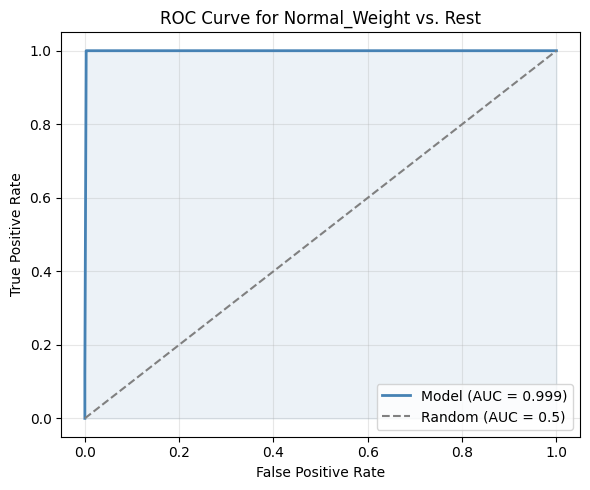

AUC: 0.9988


In [311]:
# Binarize y_test for the class 'Normal_Weight' (class 1) since prediction_proba is for class 1
y_test_binary = (y_test == 1).astype(int)

fpr, tpr, _ = roc_curve(y_test_binary, prediction_proba)
auc = roc_auc_score(y_test_binary, prediction_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Normal_Weight vs. Rest'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC: {auc:.4f}")